In [1]:
import xarray as xr
import os   
import parflow as pf
import plotly.express as px
from parflow.tools.hydrology import calculate_overland_flow_grid, calculate_subsurface_storage, calculate_water_table_depth
import numpy as np
import shutil
import json
import plotly.io as pio
import matplotlib.pyplot as mpl

In [2]:
outlet_x = 18
outlet_y = 21

In [3]:
root_dir = "/glade/derecho/scratch/bwest/drought-ensemble"
domain = "potomac_without_flow_barrier"
ensemble_name = "ensemble_1"
ensemble_member = "1_year_drought"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
no_flow_barrier = xr.open_mfdataset(files, concat_dim="time", combine="nested")


/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/bwest/conda-envs/droughts/share/proj failed
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 

In [ ]:
root_dir = "/glade/derecho/scratch/bwest/drought-ensemble"
domain = "potomac_save"
ensemble_name = "ensemble_1"
ensemble_member = "1_year_drought"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations.json"))
flow_barrier = xr.open_mfdataset(files, concat_dim="time", combine="nested")


FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/bwest/drought-ensemble/domains/potomac/processed_full_runs/ensemble_1/1_year_drought/file_locations.json'

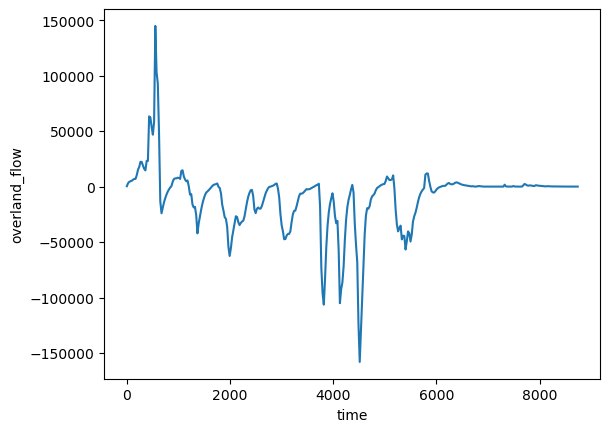

In [ ]:
start_time = 8760*8
end_time = 8760*9
streamflow_difference = no_flow_barrier.overland_flow.isel(time=slice(0, 8760,24), x=outlet_x, y=outlet_y) - flow_barrier.overland_flow.isel(time=slice(0, 8760,24), x=outlet_x, y=outlet_y)
streamflow_difference.plot()